<a href="https://colab.research.google.com/github/Halak29-6/AI_ML-Training-Batch1/blob/main/Homework/Data_preprocessing_on_Data_set_(numerical_%26categarical).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder


In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("Dataset Shape:", df.shape)
print("\n--- Column Info ---")
df.info()


Dataset Shape: (1470, 35)

--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 

In [4]:

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [5]:
cat_cols

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18',
 'OverTime']

In [7]:
null_percentages = (df.isnull().sum() / len(df)) * 100
print("\nMissing Data %")
print(null_percentages[null_percentages > 0])



Missing Data %
Series([], dtype: float64)


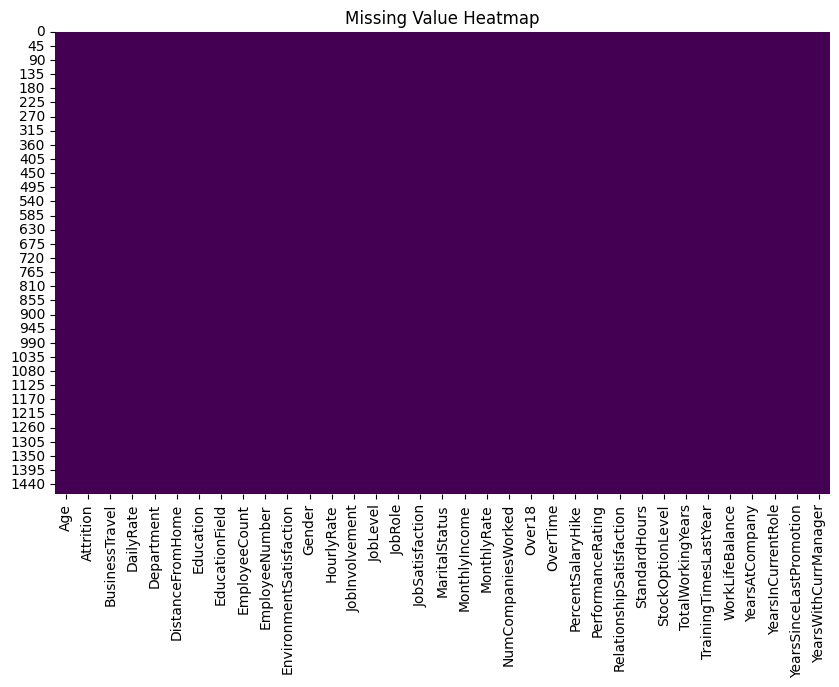

In [8]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap")
plt.show()

In [10]:
high_null_cols = null_percentages[null_percentages > 17].index.tolist()
df_cleaned = df.drop(columns=high_null_cols)

num_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_cleaned.select_dtypes(include=['object', 'category']).columns.tolist()


In [11]:

knn_imp = KNNImputer(n_neighbors=3)
df_cleaned[num_cols] = knn_imp.fit_transform(df_cleaned[num_cols])

Text(0.5, 1.0, 'Distribution of Age')

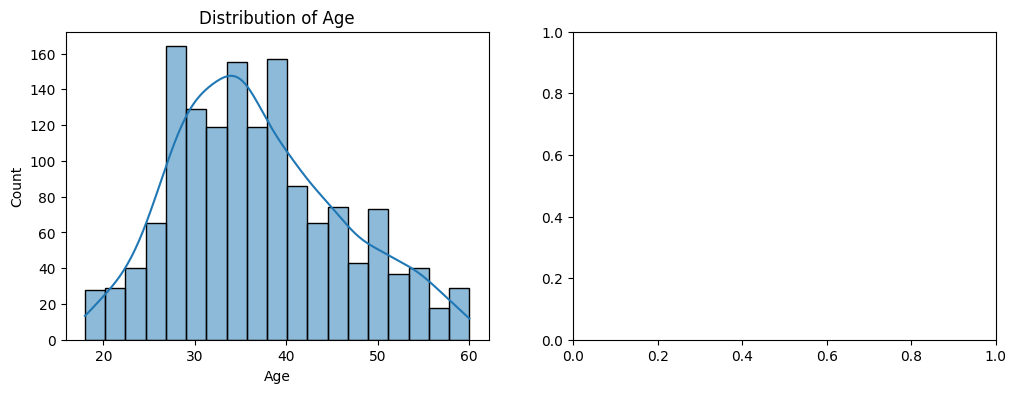

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_cleaned[num_cols[0]], kde=True, ax=axes[0])
axes[0].set_title(f'Distribution of {num_cols[0]}')

In [13]:
scaler = StandardScaler()
df_cleaned[num_cols] = scaler.fit_transform(df_cleaned[num_cols])


In [14]:
cat_imputer = SimpleImputer(strategy='most_frequent')
df_cleaned[cat_cols] = cat_imputer.fit_transform(df_cleaned[cat_cols])

In [19]:
current_cat_cols = df_cleaned.select_dtypes(include=['object', 'category']).columns.tolist()
df_cleaned = pd.get_dummies(df_cleaned, columns=current_cat_cols, drop_first=True)

# ==========================================
# STEP 5: Final Check & Summary
# ==========================================
print("\n--- Final Preprocessed Data Summary ---")
print("New Dataset Shape:", df_cleaned.shape)
print("Remaining Null Values:", df_cleaned.isnull().sum().sum())
df_cleaned.head()


--- Final Preprocessed Data Summary ---
New Dataset Shape: (1470, 48)
Remaining Null Values: 0


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,0.0,-1.701283,-0.660531,1.383138,0.379672,-0.057788,...,False,False,False,False,False,True,False,False,True,True
1,1.322365,-1.297775,-0.147150,-1.868426,0.0,-1.699621,0.254625,-0.240677,-1.026167,-0.057788,...,False,False,False,False,True,False,False,True,False,False
2,0.008343,1.414363,-0.887515,-0.891688,0.0,-1.696298,1.169781,1.284725,-1.026167,-0.961486,...,True,False,False,False,False,False,False,False,True,True
3,-0.429664,1.461466,-0.764121,1.061787,0.0,-1.694636,1.169781,-0.486709,0.379672,-0.961486,...,False,False,False,False,True,False,False,True,False,True
4,-1.086676,-0.524295,-0.887515,-1.868426,0.0,-1.691313,-1.575686,-1.274014,0.379672,-0.961486,...,True,False,False,False,False,False,False,True,False,False
